<a href="https://colab.research.google.com/github/jaredlan1/getting_started_with_ML/blob/main/ML_Final_Project_CNN_KAN_Colab_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Input (FTIR spectrum) \
→ Preprocessing layer (normalization)\
→ 1D Conv blocks (3 blocks with filters 32→64→128)\
→ Each block: Conv1D → BatchNorm → ReLU → Pool/Dropout\
→ Global Average Pooling\
→ KAN head (replacing the original dense/fully-connected regression stack)\
→ Output layer with 3 neurons (EC ratio, EMC ratio, LiPF6 molarity)\


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:

import os
import re
import copy
import warnings

%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

try:
    from efficient_kan import KAN
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        '-q',
        'git+https://github.com/Blealtan/efficient-kan.git',
    ])
    from efficient_kan import KAN

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')


Using device: cpu


Data Loading and extraction from spectral files

In [5]:


def load_ftir_data(base_directory):
    """
    Loads FTIR spectra and their corresponding labels (mole fractions) from a specified directory.

    Assumes the following file structure directly within the base_directory:
    base_directory/
    ├── spectra_ec_X_emc_Y.csv
    ├── mole_fractions_ec_X_emc_Y.csv
    ├── spectra_ec_A_emc_B.csv
    ├── mole_fractions_ec_A_emc_B.csv
    └── ...

    It's assumed that:
    - Spectra files are CSVs and contain the spectral data (e.g., wavenumber vs. absorbance).
      They are read into pandas DataFrames.
    - Label files are CSVs and contain the corresponding EC ratio, EMC ratio, and LiPF6 molarity.
      These are also read into pandas DataFrames.
    - Files have a '.csv' extension. If your files have no extension or a different one (e.g., '.txt'),
      you'll need to modify the file name construction.
    - Headers: This function assumes no headers in the CSVs (`header=None`). If your files have headers,
      remove `header=None` from `pd.read_csv`.
    - Regarding the label file name, I've used `mole_fractions` (with 'f') based on common terminology.
      If your files actually use `mole_fracttions` (with 'tt'), you will need to adjust the `labels_filename`
      variable in the function.

    Args:
        base_directory (str): The path to the directory containing the FTIR data files.

    Returns:
        tuple: A tuple containing two lists:
            - all_spectra_data (list of pd.DataFrame): List of DataFrames, each containing FTIR spectra.
            - all_labels_data (list of pd.DataFrame): List of DataFrames, each containing the labels.
    """
    all_spectra_data = []
    all_labels_data = []
    processed_count = 0

    # Regex to match the file name format 'spectra_ec_X_emc_Y.csv' or 'mole_fractions_ec_X_emc_Y.csv'
    # Example: 'spectra_ec_0_emc_100.csv' -> groups 1='spectra', 2='0', 3='100'
    file_pattern = re.compile(r'(spectra|mole_fractions)_ec_(\d+)_emc_(\d+)\.csv')

    if not os.path.isdir(base_directory):
        print(f"Error: Base directory '{base_directory}' does not exist.")
        return [], []

    spectra_files_map = {}
    labels_files_map = {}

    # Iterate through all files in the base directory
    for entry_name in os.listdir(base_directory):
        full_entry_path = os.path.join(base_directory, entry_name)

        if os.path.isfile(full_entry_path):
            file_match = file_pattern.match(entry_name)
            if file_match:
                file_type = file_match.group(1)
                ec_val = file_match.group(2)
                emc_val = file_match.group(3)
                key = (ec_val, emc_val)

                if file_type == 'spectra':
                    spectra_files_map[key] = full_entry_path
                elif file_type == 'mole_fractions':
                    labels_files_map[key] = full_entry_path

    # Now, try to pair and load the data
    for key, spectra_file_path in spectra_files_map.items():
        if key in labels_files_map:
            labels_file_path = labels_files_map[key]
            try:
                spectra_df = pd.read_csv(spectra_file_path, header=None) # Assuming no header
                labels_df = pd.read_csv(labels_file_path, header=None) # Assuming no header

                all_spectra_data.append(spectra_df)
                all_labels_data.append(labels_df)
                processed_count += 1
            except Exception as e:
                print(f"Error loading files for key {key}: {e}")
        else:
            print(f"Warning: No corresponding mole_fractions file found for spectra key {key}. Skipping.")

    print(f"Successfully processed {processed_count} sets of FTIR data.")
    return all_spectra_data, all_labels_data

In [6]:
# Replace with the actual path to your 'Spectral_analysis' directory
base_data_path = "/content/drive/MyDrive/Machine Learning/Spectra"
# Load the data
ftir_spectra, ftir_labels = load_ftir_data(base_data_path)

# You can then inspect the loaded data:
print(f"\nTotal spectra loaded: {len(ftir_spectra)}")
print(f"Total labels loaded: {len(ftir_labels)}")

if ftir_spectra:
    print("\nFirst spectra DataFrame (head):")
    display(ftir_spectra[0].head())

if ftir_labels:
    print("\nFirst labels DataFrame:")
    display(ftir_labels[0])

Successfully processed 6 sets of FTIR data.

Total spectra loaded: 6
Total labels loaded: 6

First spectra DataFrame (head):


,0,1,2,3,4,5,6,7
0,Wavenumber (cm^-1),0M,0.6M,0.8M,1M,1.2M,1.4M,1.8M
1,400.1635,0.043900841,0.063278564,0.099383782,0.169694206,0.169225008,0.228926422,0.297219707
2,400.6456,0.034292191,0.049343506,0.084913704,0.15924575,0.159116456,0.208143364,0.29464384
3,401.1277,0.022835844,0.034552047,0.068925758,0.148116369,0.147497339,0.185109925,0.284951225
4,401.6098,0.010157736,0.019479991,0.053806762,0.136729216,0.136237448,0.162428552,0.269727696



First labels DataFrame:


,0,1,2,3
0,Molarity (mol/L),Mole % LiPF6,Mole % EC,Mole % EMC
1,0,0,0,1
2,0.6,0.058954562,0,0.941045438
3,0.8,0.077091125,0,0.922908875
4,1,0.094541822,0,0.905458178
5,1.2,0.111344837,0,0.888655163
6,1.4,0.127535572,0,0.872464428
7,1.8,0.158209358,0,0.841790642


In [7]:
# Check the data structure
print(f"Number of EC/EMC ratio combinations: {len(ftir_spectra)}")
print(f"Number of label sets: {len(ftir_labels)}")

# Explore the first spectra DataFrame
if ftir_spectra:
    first_spectra = ftir_spectra[0]
    print(f"\nFirst spectra DataFrame shape: {first_spectra.shape}")
    print(f"Columns in spectra: {first_spectra.shape[1]} (1 wavenumber column + {first_spectra.shape[1]-1} sample columns)")

    # Check if first column is wavenumber (should be consistent across samples)
    print(f"\nFirst few wavenumber values:")
    print(first_spectra.iloc[:5, 0])

    # Check the sample columns
    print(f"\nSample column names (if headers exist):")
    print(first_spectra.columns.tolist())

# Explore the first labels DataFrame
if ftir_labels:
    first_labels = ftir_labels[0]
    print(f"\nFirst labels DataFrame shape: {first_labels.shape}")
    print(f"Labels content:")
    display(first_labels)



Number of EC/EMC ratio combinations: 6
Number of label sets: 6

First spectra DataFrame shape: (3313, 8)
Columns in spectra: 8 (1 wavenumber column + 7 sample columns)

First few wavenumber values:
0    Wavenumber (cm^-1)
1              400.1635
2              400.6456
3              401.1277
4              401.6098
Name: 0, dtype: object

Sample column names (if headers exist):
[0, 1, 2, 3, 4, 5, 6, 7]

First labels DataFrame shape: (8, 4)
Labels content:


,0,1,2,3
0,Molarity (mol/L),Mole % LiPF6,Mole % EC,Mole % EMC
1,0,0,0,1
2,0.6,0.058954562,0,0.941045438
3,0.8,0.077091125,0,0.922908875
4,1,0.094541822,0,0.905458178
5,1.2,0.111344837,0,0.888655163
6,1.4,0.127535572,0,0.872464428
7,1.8,0.158209358,0,0.841790642


In [8]:
# First, let's inspect the actual structure
print("Inspecting first spectra DataFrame:")
print(ftir_spectra[0].head(10))
print("\nInspecting first labels DataFrame:")
print(ftir_labels[0].head(10))
# Rebuild labels correctly - skip the header row and select only numeric columns
all_labels_list = []
all_spectra_list = []

for spec_df, label_df in zip(ftir_spectra, ftir_labels):
    # Extract spectra (skip wavenumber column 0 AND header row 0)
    for col_idx in range(1, spec_df.shape[1]):
        # Convert spectrum to float immediately after extraction
        spectrum = spec_df.iloc[1:, col_idx].values.astype(float)
        all_spectra_list.append(spectrum)

    # Extract labels - skip row 0 (header) and convert to float
    # Columns should be: [Molarity, Mole % LiPF6, Mole % EC, Mole % EMC]
    for row_idx in range(1, len(label_df)):
        try:
            # Extract all 4 columns and convert to float
            label_row = label_df.iloc[row_idx, :].values.astype(float)
            all_labels_list.append(label_row)
        except ValueError as e:
            print(f"Error at row {row_idx}: {label_df.iloc[row_idx, :].values}")
            raise e

# Convert to numpy arrays
X = np.array(all_spectra_list, dtype=float)
y = np.array(all_labels_list, dtype=float)

print(f"{'='*60}")
print(f"CLEANED DATASET:")
print(f"{'='*60}")
print(f"X shape: {X.shape}, dtype: {X.dtype}")
print(f"y shape: {y.shape}, dtype: {y.dtype}")
print(f"\nFirst 5 labels (should be all numeric):")
print(y[:5])
print(f"\nLabel statistics:")
print(f"  Molarity range: [{y[:, 0].min():.2f}, {y[:, 0].max():.2f}]")
print(f"  LiPF6 % range: [{y[:, 1].min():.4f}, {y[:, 1].max():.4f}]")
print(f"  EC % range: [{y[:, 2].min():.4f}, {y[:, 2].max():.4f}]")
print(f"  EMC % range: [{y[:, 3].min():.4f}, {y[:, 3].max():.4f}]")

Inspecting first spectra DataFrame:
                    0             1             2            3            4  \
0  Wavenumber (cm^-1)            0M          0.6M         0.8M           1M   
1            400.1635   0.043900841   0.063278564  0.099383782  0.169694206   
2            400.6456   0.034292191   0.049343506  0.084913704   0.15924575   
3            401.1277   0.022835844   0.034552047  0.068925758  0.148116369   
4            401.6098   0.010157736   0.019479991  0.053806762  0.136729216   
5            402.0919  -0.002894712   0.004442951  0.042091056  0.126303187   
6            402.5741   -0.01517375  -0.010201407  0.035891669  0.118502907   
7            403.0562  -0.025341235  -0.023742286  0.036369572  0.114846266   
8            403.5383  -0.032126795  -0.035004516  0.043421487   0.11613521   
9            404.0204   -0.03460227  -0.042534327   0.05570872  0.122190641   

             5            6            7  
0         1.2M         1.4M         1.8M  
1  0.169

FTIR Spectroscopy Multi-Component Prediction Pipeline
Predicts:\
 Molarity, Mole % LiPF6, Mole % EC, Mole % EMC


2. PREPROCESSING



In [9]:
class SpectralAugmenter:
    """Augment FTIR spectra to increase dataset size"""

    def __init__(self, noise_level=0.01, baseline_range=0.02,
                 intensity_range=0.05, shift_range=5):
        self.noise_level = noise_level
        self.baseline_range = baseline_range
        self.intensity_range = intensity_range
        self.shift_range = shift_range

    def add_noise(self, spectrum):
        """Add Gaussian noise"""
        noise = np.random.normal(0, self.noise_level, spectrum.shape)
        return spectrum + noise

    def baseline_shift(self, spectrum):
        """Add baseline shift and tilt"""
        shift = np.random.uniform(-self.baseline_range, self.baseline_range)
        tilt = np.random.uniform(-self.baseline_range/2, self.baseline_range/2)
        x = np.linspace(-1, 1, len(spectrum))
        return spectrum + shift + tilt * x

    def intensity_scale(self, spectrum):
        """Scale intensity"""
        scale = np.random.uniform(1 - self.intensity_range, 1 + self.intensity_range)
        return spectrum * scale

    def spectral_shift(self, spectrum):
        """Shift spectrum along wavenumber axis"""
        shift = np.random.randint(-self.shift_range, self.shift_range + 1)
        if shift == 0:
            return spectrum
        return np.roll(spectrum, shift)

    def augment(self, spectrum, n_augmentations=1):
        """Apply random augmentations"""
        augmented = []
        for _ in range(n_augmentations):
            aug_spec = spectrum.copy()
            # Randomly apply 2-3 augmentations
            if np.random.rand() > 0.3:
                aug_spec = self.add_noise(aug_spec)
            if np.random.rand() > 0.3:
                aug_spec = self.baseline_shift(aug_spec)
            if np.random.rand() > 0.3:
                aug_spec = self.intensity_scale(aug_spec)
            if np.random.rand() > 0.5:
                aug_spec = self.spectral_shift(aug_spec)
            augmented.append(aug_spec)
        return np.array(augmented)

def augment_dataset(X, y, augmentation_factor=5):
    """Augment entire dataset"""
    augmenter = SpectralAugmenter()
    X_augmented = [X]
    y_augmented = [y]

    for i in range(len(X)):
        aug_spectra = augmenter.augment(X[i], n_augmentations=augmentation_factor-1)
        X_augmented.append(aug_spectra)
        y_augmented.append(np.tile(y[i], (augmentation_factor-1, 1)))

    X_aug = np.vstack(X_augmented)
    y_aug = np.vstack(y_augmented)

    # Shuffle
    indices = np.random.permutation(len(X_aug))
    return X_aug[indices], y_aug[indices]


In [10]:
def preprocess_spectra(X_train, X_test=None):
    """Standardize spectra"""
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    if X_test is not None:
        X_test_scaled = scaler.transform(X_test)
        return X_train_scaled, X_test_scaled, scaler
    return X_train_scaled, scaler

3. MODEL ARCHITECTURES


### CNN backbone vs. MLP head in the original model

**Original CNN backbone (kept architecturally unchanged):**
- `Conv1D(32, kernel_size=11, activation='relu')`
- `BatchNormalization()`
- `MaxPooling1D(pool_size=2)`
- `Dropout(dropout_rate)`
- `Conv1D(64, kernel_size=7, activation='relu')`
- `BatchNormalization()`
- `MaxPooling1D(pool_size=2)`
- `Dropout(dropout_rate)`
- `Conv1D(128, kernel_size=5, activation='relu')`
- `BatchNormalization()`
- `GlobalAveragePooling1D()`
- `Dropout(dropout_rate)`

**Original MLP head (replaced with KAN):**
- `Dense(64, activation='relu')`
- `Dropout(dropout_rate)`
- `Dense(32, activation='relu')`
- `Dense(n_outputs)`

This notebook keeps the convolutional feature extractor intact and replaces only the dense prediction stack with an `efficient-kan` head. `efficient-kan` is used instead of `pykan` because it is more memory-efficient and faster in PyTorch for typical training workloads.


In [11]:

class SpectraTensorDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class CNNFeatureExtractor1D(nn.Module):
    """Original 1D CNN feature extractor, preserved from the Keras model."""

    def __init__(self, dropout_rate=0.4):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=11)
        self.bn1 = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        self.drop1 = nn.Dropout(dropout_rate)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=7)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        self.drop2 = nn.Dropout(dropout_rate)

        self.conv3 = nn.Conv1d(64, 128, kernel_size=5)
        self.bn3 = nn.BatchNorm1d(128)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.drop3 = nn.Dropout(dropout_rate)

    def forward(self, x):
        # Expected input is [batch, length] or [batch, 1, length].
        if x.dim() == 2:
            x = x.unsqueeze(1)
        elif x.dim() == 3 and x.shape[1] != 1 and x.shape[2] == 1:
            # TODO: Confirm upstream tensors are consistently channel-first.
            #       This transpose handles [batch, length, 1] inputs from legacy code.
            x = x.transpose(1, 2)
        elif x.dim() != 3:
            raise ValueError(f'Expected 2D or 3D tensor, got shape {tuple(x.shape)}')

        x = self.conv1(x)
        x = torch.relu(x)
        x = self.bn1(x)
        x = self.pool1(x)
        x = self.drop1(x)

        x = self.conv2(x)
        x = torch.relu(x)
        x = self.bn2(x)
        x = self.pool2(x)
        x = self.drop2(x)

        x = self.conv3(x)
        x = torch.relu(x)
        x = self.bn3(x)
        x = self.global_pool(x).squeeze(-1)
        x = self.drop3(x)
        return x


class CNNKANRegressor(nn.Module):
    def __init__(
        self,
        input_length,
        n_outputs=3,
        dropout_rate=0.4,
        kan_hidden_dims=(64, 32),
        grid_size=5,
        spline_order=3,
    ):
        super().__init__()
        self.feature_extractor = CNNFeatureExtractor1D(dropout_rate=dropout_rate)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_length)
            feature_dim = self.feature_extractor(dummy).shape[1]

        self.feature_dim = feature_dim
        self.n_outputs = n_outputs

        # Why KAN here:
        # - KAN replaces fixed linear weights + pointwise activations with learnable spline-based
        #   univariate functions, which can be attractive for spectroscopy because it may expose
        #   more interpretable nonlinear responses to learned spectral features.
        # - For EC/EMC/Li-salt spectral regression, tune these first: (1) kan_hidden_dims,
        #   (2) grid_size, (3) spline_order, and then (4) kan regularization strength.
        # - Start small. Spectral datasets like this are often limited in sample count, so a large
        #   KAN head can overfit faster than the old dense stack.
        self.kan_head = KAN(
            layers_hidden=[feature_dim, *list(kan_hidden_dims), n_outputs],
            grid_size=grid_size,
            spline_order=spline_order,
        )

    def forward(self, x, update_grid=False):
        features = self.feature_extractor(x)
        try:
            return self.kan_head(features, update_grid=update_grid)
        except TypeError:
            # TODO: Some efficient-kan versions may not expose update_grid in forward().
            return self.kan_head(features)


def build_1d_cnn_kan(
    input_length,
    n_outputs=3,
    dropout_rate=0.4,
    kan_hidden_dims=(64, 32),
    grid_size=5,
    spline_order=3,
):
    return CNNKANRegressor(
        input_length=input_length,
        n_outputs=n_outputs,
        dropout_rate=dropout_rate,
        kan_hidden_dims=kan_hidden_dims,
        grid_size=grid_size,
        spline_order=spline_order,
    )


4. TRAINING AND EVALUATION

In [12]:
def evaluate_predictions(y_true, y_pred, target_names):
    """Calculate and display metrics"""
    results = {}

    for i, name in enumerate(target_names):
        mse = mean_squared_error(y_true[:, i], y_pred[:, i])
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        r2 = r2_score(y_true[:, i], y_pred[:, i])

        results[name] = {
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2
        }

    return results

def plot_predictions(y_true, y_pred, target_names, title="Predictions vs Actual"):
    """Plot prediction results"""
    n_targets = y_true.shape[1]
    fig, axes = plt.subplots(1, n_targets, figsize=(5*n_targets, 4))

    if n_targets == 1:
        axes = [axes]

    for i, (ax, name) in enumerate(zip(axes, target_names)):
        ax.scatter(y_true[:, i], y_pred[:, i], alpha=0.6, s=50)

        # Perfect prediction line
        min_val = min(y_true[:, i].min(), y_pred[:, i].min())
        max_val = max(y_true[:, i].max(), y_pred[:, i].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')

        # Metrics
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))

        ax.set_xlabel(f'Actual {name}', fontsize=11)
        ax.set_ylabel(f'Predicted {name}', fontsize=11)
        ax.set_title(f'{name}\nR² = {r2:.3f}, RMSE = {rmse:.4f}', fontsize=11)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# 5. CROSS-VALIDATION FRAMEWORK

In [13]:

def _conv_l2_penalty(model):
    # Approximates the original Keras kernel_regularizer on convolutional weights.
    # TODO: The original dense-layer L2 penalty cannot be matched exactly once the dense
    #       head is replaced by KAN, because the head no longer uses nn.Linear kernels.
    return (
        model.feature_extractor.conv1.weight.pow(2).sum()
        + model.feature_extractor.conv2.weight.pow(2).sum()
        + model.feature_extractor.conv3.weight.pow(2).sum()
    )


def train_torch_regressor(
    model,
    train_loader,
    val_loader,
    epochs=100,
    learning_rate=1e-3,
    patience=20,
    conv_l2_lambda=1e-3,
    kan_reg_strength=0.0,
    regularize_activation=1.0,
    regularize_entropy=1.0,
):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    best_state = None
    best_val_loss = float('inf')
    best_epoch = 0
    epochs_without_improvement = 0
    history = {'train_loss': [], 'val_loss': []}

    model.to(DEVICE)

    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss = loss + conv_l2_lambda * _conv_l2_penalty(model)

            if kan_reg_strength > 0.0:
                if hasattr(model.kan_head, 'regularization_loss'):
                    loss = loss + kan_reg_strength * model.kan_head.regularization_loss(
                        regularize_activation=regularize_activation,
                        regularize_entropy=regularize_entropy,
                    )
                else:
                    # TODO: If your installed efficient-kan version lacks regularization_loss(),
                    #       keep kan_reg_strength=0.0 or add your own spline regularizer here.
                    pass

            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * xb.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                preds = model(xb)
                val_loss = criterion(preds, yb)
                val_loss = val_loss + conv_l2_lambda * _conv_l2_penalty(model)
                running_val_loss += val_loss.item() * xb.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)

        if epoch_val_loss < best_val_loss - 1e-8:
            best_val_loss = epoch_val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_epoch


def predict_torch_regressor(model, data_loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in data_loader:
            xb = xb.to(DEVICE)
            batch_preds = model(xb)
            preds.append(batch_preds.cpu().numpy())
    return np.vstack(preds)


def cross_validate_cnn_kan(
    X,
    y,
    n_folds=5,
    epochs=100,
    batch_size=8,
    use_augmentation=True,
    dropout_rate=0.4,
    kan_hidden_dims=(64, 32),
    grid_size=5,
    spline_order=3,
    kan_reg_strength=0.0,
):
    """Cross-validate 1D-CNN with a KAN head."""
    print(f"\n{'='*60}")
    print(f"1D-CNN + KAN head{' with Augmentation' if use_augmentation else ''}")
    print(f"{'='*60}")

    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    y_pred_all = np.zeros_like(y, dtype=np.float32)

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"\nFold {fold + 1}/{n_folds}")

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        if use_augmentation:
            X_train_aug, y_train_aug = augment_dataset(X_train, y_train, augmentation_factor=5)
            print(f"  Training samples: {len(X_train)} -> {len(X_train_aug)} (augmented)")
        else:
            X_train_aug, y_train_aug = X_train, y_train

        X_train_scaled, X_val_scaled, _ = preprocess_spectra(X_train_aug, X_val)

        train_dataset = SpectraTensorDataset(X_train_scaled, y_train_aug)
        val_dataset = SpectraTensorDataset(X_val_scaled, y_val)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

        model = build_1d_cnn_kan(
            input_length=X_train_scaled.shape[1],
            n_outputs=y.shape[1],
            dropout_rate=dropout_rate,
            kan_hidden_dims=kan_hidden_dims,
            grid_size=grid_size,
            spline_order=spline_order,
        )

        model, history, best_epoch = train_torch_regressor(
            model,
            train_loader,
            val_loader,
            epochs=epochs,
            learning_rate=1e-3,
            patience=20,
            conv_l2_lambda=1e-3,
            kan_reg_strength=kan_reg_strength,
        )

        y_pred_all[val_idx] = predict_torch_regressor(model, val_loader)
        print(f"  Best epoch: {best_epoch + 1}")

    return y_pred_all


# Backward-compatible alias if downstream cells still call the old function name.
cross_validate_cnn = cross_validate_cnn_kan


 6. MAIN EXECUTION

In [14]:
def cross_validate_pls(X, y, n_components=10, n_folds=5):
    """
    Cross-validated PLS regression predictions.

    Notes:
    - Uses manual KFold so n_components can be clipped per fold to the
      maximum valid value for that training split.
    - Assumes X is already preprocessed/scaled upstream if desired.
    """
    print(f"\n{'='*60}")
    print("PLS Regression")
    print(f"{'='*60}")

    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    y_pred_all = np.zeros_like(y, dtype=np.float32)

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"\nFold {fold + 1}/{n_folds}")

        X_train, X_val = X[train_idx], X[val_idx]
        y_train = y[train_idx]

        max_components = min(X_train.shape[0] - 1, X_train.shape[1], y_train.shape[1] if y_train.ndim > 1 else 1)
        # TODO: If you want more aggressive latent compression, tune n_components first.
        #       With tiny spectral datasets, asking for too many components is just noise fitting.
        n_comp_fold = max(1, min(n_components, max_components))

        model = PLSRegression(n_components=n_comp_fold)
        model.fit(X_train, y_train)
        y_pred_all[val_idx] = model.predict(X_val)

        print(f"  Using n_components={n_comp_fold}")

    return y_pred_all


def cross_validate_rf(X, y, n_folds=5, n_estimators=200, max_depth=None):
    """
    Cross-validated Random Forest predictions.
    """
    print(f"\n{'='*60}")
    print("Random Forest")
    print(f"{'='*60}")

    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    y_pred_all = np.zeros_like(y, dtype=np.float32)

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"\nFold {fold + 1}/{n_folds}")

        X_train, X_val = X[train_idx], X[val_idx]
        y_train = y[train_idx]

        model = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42,
            n_jobs=-1,
        )
        model.fit(X_train, y_train)
        y_pred_all[val_idx] = model.predict(X_val)

    return y_pred_all


In [15]:

def run_full_pipeline(
    X,
    y,
    target_names,
    kan_hidden_dims=(64, 32),
    grid_size=5,
    spline_order=3,
    kan_reg_strength=0.0,
):
    """Run complete evaluation pipeline."""

    print(f"\n{'#'*60}")
    print("FTIR MULTI-COMPONENT PREDICTION PIPELINE")
    print(f"{'#'*60}")
    print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
    print(f"Targets: {target_names}")

    X_scaled, _ = preprocess_spectra(X)

    y_pred_pls = cross_validate_pls(X_scaled, y, n_components=10, n_folds=5)
    results_pls = evaluate_predictions(y, y_pred_pls, target_names)

    print("\nPLS Results:")
    results_df = pd.DataFrame(results_pls).T
    print(results_df.to_string())
    plot_predictions(y, y_pred_pls, target_names, "PLS Regression - Cross-Validated")

    y_pred_rf = cross_validate_rf(X_scaled, y, n_folds=5)
    results_rf = evaluate_predictions(y, y_pred_rf, target_names)

    print("\nRandom Forest Results:")
    results_df = pd.DataFrame(results_rf).T
    print(results_df.to_string())
    plot_predictions(y, y_pred_rf, target_names, "Random Forest - Cross-Validated")

    y_pred_cnn_kan = cross_validate_cnn_kan(
        X,
        y,
        n_folds=5,
        epochs=100,
        batch_size=8,
        use_augmentation=False,
        kan_hidden_dims=kan_hidden_dims,
        grid_size=grid_size,
        spline_order=spline_order,
        kan_reg_strength=kan_reg_strength,
    )
    results_cnn_kan = evaluate_predictions(y, y_pred_cnn_kan, target_names)

    print("\n1D-CNN + KAN (No Augmentation) Results:")
    results_df = pd.DataFrame(results_cnn_kan).T
    print(results_df.to_string())
    plot_predictions(y, y_pred_cnn_kan, target_names, "1D-CNN + KAN - Cross-Validated (No Aug)")

    y_pred_cnn_kan_aug = cross_validate_cnn_kan(
        X,
        y,
        n_folds=5,
        epochs=100,
        batch_size=8,
        use_augmentation=True,
        kan_hidden_dims=kan_hidden_dims,
        grid_size=grid_size,
        spline_order=spline_order,
        kan_reg_strength=kan_reg_strength,
    )
    results_cnn_kan_aug = evaluate_predictions(y, y_pred_cnn_kan_aug, target_names)

    print("\n1D-CNN + KAN (With Augmentation) Results:")
    results_df = pd.DataFrame(results_cnn_kan_aug).T
    print(results_df.to_string())
    plot_predictions(y, y_pred_cnn_kan_aug, target_names, "1D-CNN + KAN - Cross-Validated (With Aug)")

    print(f"\n{'='*60}")
    print("MODEL COMPARISON (Average R² Score)")
    print(f"{'='*60}")

    models = ['PLS', 'Random Forest', 'CNN+KAN (No Aug)', 'CNN+KAN (Aug)']
    all_results = [results_pls, results_rf, results_cnn_kan, results_cnn_kan_aug]

    comparison = {}
    for model_name, results in zip(models, all_results):
        avg_r2 = np.mean([results[target]['R2'] for target in target_names])
        comparison[model_name] = avg_r2
        print(f"{model_name:20s}: {avg_r2:.3f}")

    print(f"\nBest model: {max(comparison, key=comparison.get)}")

    return {
        'pls': (y_pred_pls, results_pls),
        'rf': (y_pred_rf, results_rf),
        'cnn_kan': (y_pred_cnn_kan, results_cnn_kan),
        'cnn_kan_aug': (y_pred_cnn_kan_aug, results_cnn_kan_aug),
    }


USAGE EXAMPLE



############################################################
FTIR MULTI-COMPONENT PREDICTION PIPELINE
############################################################
Dataset: 42 samples, 3312 features
Targets: ['Molarity (mol/L)', 'Mole % LiPF6', 'Mole % EC']

PLS Regression

Fold 1/5
  Using n_components=3

Fold 2/5
  Using n_components=3

Fold 3/5
  Using n_components=3

Fold 4/5
  Using n_components=3

Fold 5/5
  Using n_components=3

PLS Results:
                      RMSE       MAE        R2
Molarity (mol/L)  0.118880  0.089118  0.951370
Mole % LiPF6      0.012464  0.009821  0.909957
Mole % EC         0.256645  0.228414  0.093278


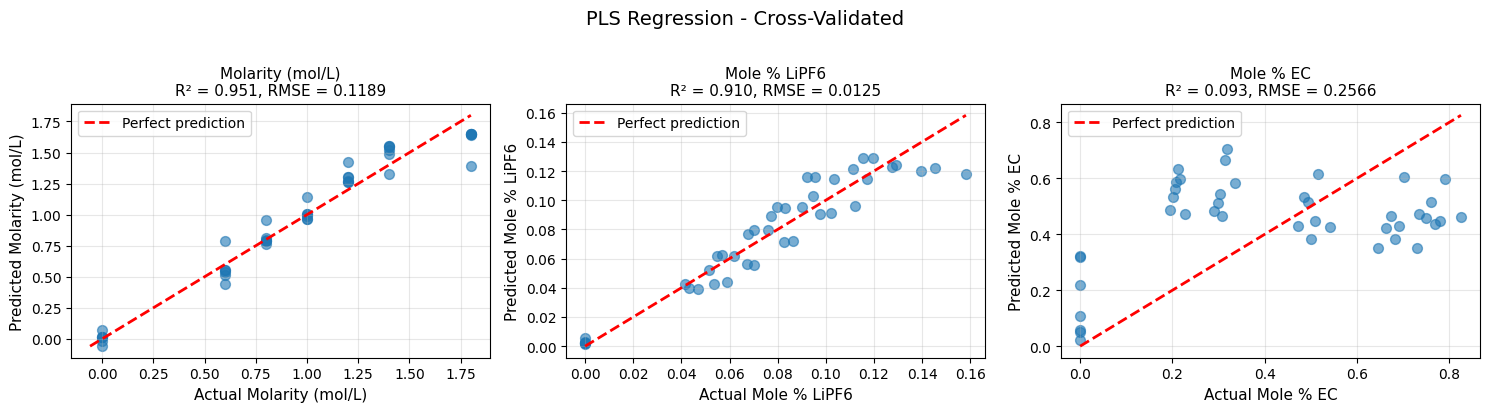


Random Forest

Fold 1/5


In [ ]:

# This is what you already created:
X = np.array(all_spectra_list)  # Shape: (n_samples, n_wavenumbers)
y = np.array(all_labels_list)[:, :3]  # [Molarity, LiPF6%, EC%]

# TODO: If you switch to classification targets, update y dtype/encoding, the output dimension,
#       and the criterion in train_torch_regressor (e.g., CrossEntropyLoss or BCEWithLogitsLoss).

target_names = ['Molarity (mol/L)', 'Mole % LiPF6', 'Mole % EC']

results = run_full_pipeline(
    X,
    y,
    target_names,
    kan_hidden_dims=(64, 32),
    grid_size=5,
    spline_order=3,
    kan_reg_strength=0.0,  # Start at 0.0 to preserve the original training objective as closely as possible.
)
